# 🧠 3D Generative Models: GANs, VAE-GANs & Diffusion

This notebook covers three powerful generative model families applied to 2D and 3D data:

| Model | Dataset | Task |
|---|---|---|
| **VAE-GAN** | MNIST (torchvision) | Latent-space image generation |
| **3D Voxel GAN** | Synthetic 3D shapes | Volumetric shape generation |
| **DDPM (Diffusion)** | MNIST (torchvision) | Score-based denoising generation |

All models are designed to **train to visible results in minutes** on a CPU or GPU.

## 📦 Install & Imports

In [1]:
!pip install torch torchvision matplotlib numpy tqdm -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


---
# Part 1 — VAE-GAN on MNIST

The VAE-GAN combines:
- **Encoder** → maps images to a latent distribution `q(z|x)`
- **Decoder/Generator** → reconstructs images from `z`
- **Discriminator** → separates real from generated

Training jointly optimises: `L = L_reconstruction + L_KL + L_GAN`

In [3]:
# ── Dataset ──────────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # → [-1, 1]
])

mnist_train = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
mnist_loader = DataLoader(mnist_train, batch_size=128, shuffle=True, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.09MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.44MB/s]


In [4]:
# ── Architecture ─────────────────────────────────────────────────────────────
LATENT_DIM = 64

class Encoder(nn.Module):
    """Convolutional encoder → (mu, log_var) for reparameterisation."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 28→14
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1), # 14→7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.fc_mu  = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_var = nn.Linear(128 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_var(h)


class Decoder(nn.Module):
    """Transposed-conv decoder latent → image."""
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 7 * 7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 7→14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 14→28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 128, 7, 7)
        return self.net(h)


class Discriminator(nn.Module):
    """PatchGAN-style discriminator."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
        )

    def forward(self, x):
        return self.net(x)

In [5]:
# ── Training helpers ──────────────────────────────────────────────────────────
def reparameterise(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std


def kl_loss(mu, log_var):
    return -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())


def plot_samples(imgs, title, n=16, figsize=(8, 2)):
    imgs = imgs[:n].detach().cpu() * 0.5 + 0.5  # denorm
    grid = torchvision.utils.make_grid(imgs, nrow=n, padding=2)
    plt.figure(figsize=figsize)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
# ── Initialise models & optimisers ────────────────────────────────────────────
enc = Encoder().to(DEVICE)
dec = Decoder().to(DEVICE)
disc = Discriminator().to(DEVICE)

opt_enc  = optim.Adam(enc.parameters(),  lr=2e-4, betas=(0.5, 0.999))
opt_dec  = optim.Adam(dec.parameters(),  lr=2e-4, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

VAE_GAN_EPOCHS  = 10
LAMBDA_KL       = 0.01   # weight for KL term
LAMBDA_REC      = 10.0   # weight for reconstruction term

history = {'d_loss': [], 'g_loss': [], 'rec_loss': [], 'kl_loss': []}

Epoch 01 | D: 0.962 | G: 4.026 | Rec: 1.098 | KL: 0.0380


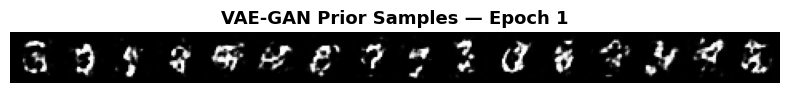

Epoch 02 | D: 1.095 | G: 2.869 | Rec: 0.420 | KL: 0.0449


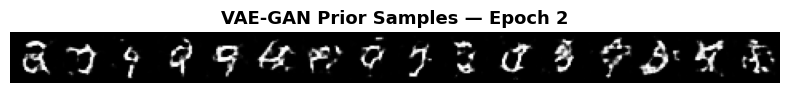

Epoch 03 | D: 1.126 | G: 2.708 | Rec: 0.387 | KL: 0.0440


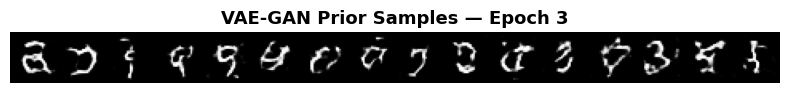

Epoch 04 | D: 1.138 | G: 2.623 | Rec: 0.362 | KL: 0.0465


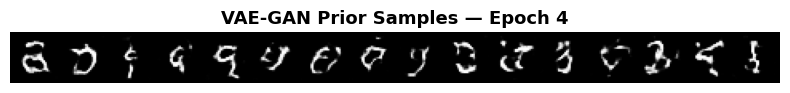

Epoch 05 | D: 1.153 | G: 2.582 | Rec: 0.349 | KL: 0.0472


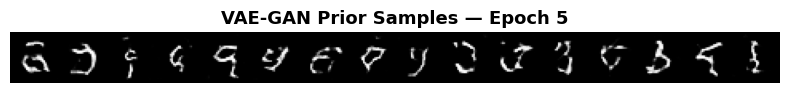

Epoch 06 | D: 1.170 | G: 2.522 | Rec: 0.341 | KL: 0.0458


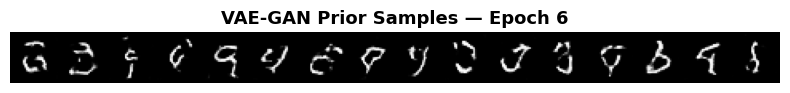

Epoch 07 | D: 1.175 | G: 2.484 | Rec: 0.334 | KL: 0.0439


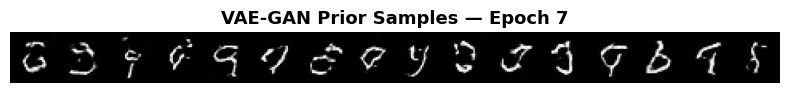

Epoch 08 | D: 1.187 | G: 2.440 | Rec: 0.320 | KL: 0.0427


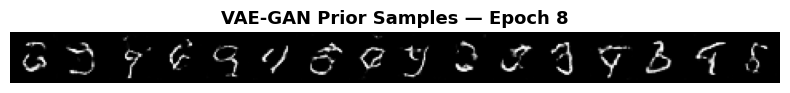

Epoch 09 | D: 1.184 | G: 2.427 | Rec: 0.309 | KL: 0.0420


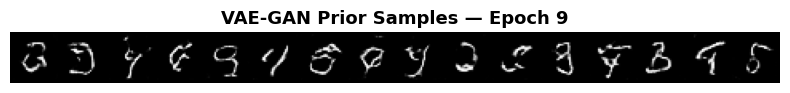

Epoch 10 | D: 1.185 | G: 2.422 | Rec: 0.301 | KL: 0.0410


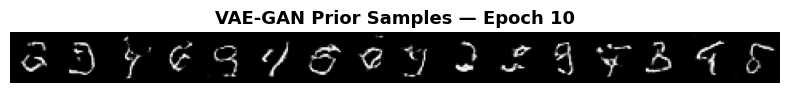

In [7]:
# ── Training loop ─────────────────────────────────────────────────────────────
fixed_noise = torch.randn(16, LATENT_DIM, device=DEVICE)

for epoch in range(1, VAE_GAN_EPOCHS + 1):
    enc.train(); dec.train(); disc.train()
    ep_d, ep_g, ep_r, ep_k = 0., 0., 0., 0.

    for real, _ in tqdm(mnist_loader, desc=f'VAE-GAN Epoch {epoch}/{VAE_GAN_EPOCHS}', leave=False):
        real = real.to(DEVICE)
        bs   = real.size(0)
        ones = torch.ones(bs, 1, device=DEVICE)
        zeros = torch.zeros(bs, 1, device=DEVICE)

        # ── 1. Encode & decode real images ──────────────────────────────────
        mu, log_var = enc(real)
        z_enc       = reparameterise(mu, log_var)
        recon       = dec(z_enc)

        # Sample from prior
        z_prior     = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_prior  = dec(z_prior)

        # ── 2. Discriminator update ──────────────────────────────────────────
        opt_disc.zero_grad()
        d_real  = bce(disc(real),         ones)
        d_recon = bce(disc(recon.detach()), zeros)
        d_prior = bce(disc(fake_prior.detach()), zeros)
        d_loss  = (d_real + 0.5 * d_recon + 0.5 * d_prior)
        d_loss.backward()
        opt_disc.step()

        # ── 3. Generator / Decoder update ───────────────────────────────────
        opt_dec.zero_grad()
        rec_loss = mse(recon, real) * LAMBDA_REC
        g_recon  = bce(disc(recon),       ones)   # fool discriminator
        g_prior  = bce(disc(fake_prior),  ones)
        g_loss   = rec_loss + g_recon + g_prior
        g_loss.backward(retain_graph=True)
        opt_dec.step()

        # ── 4. Encoder update ────────────────────────────────────────────────
        opt_enc.zero_grad()
        mu2, log_var2 = enc(real)
        z2 = reparameterise(mu2, log_var2)
        recon2   = dec(z2)
        kl       = kl_loss(mu2, log_var2) * LAMBDA_KL
        enc_rec  = mse(recon2, real) * LAMBDA_REC
        enc_loss = kl + enc_rec
        enc_loss.backward()
        opt_enc.step()

        ep_d += d_loss.item()
        ep_g += g_loss.item()
        ep_r += enc_rec.item()
        ep_k += kl.item()

    n = len(mnist_loader)
    history['d_loss'].append(ep_d / n)
    history['g_loss'].append(ep_g / n)
    history['rec_loss'].append(ep_r / n)
    history['kl_loss'].append(ep_k / n)

    print(f'Epoch {epoch:02d} | D: {ep_d/n:.3f} | G: {ep_g/n:.3f} | '
          f'Rec: {ep_r/n:.3f} | KL: {ep_k/n:.4f}')

    # Visualise
    enc.eval(); dec.eval()
    with torch.no_grad():
        gen = dec(fixed_noise)
    plot_samples(gen, f'VAE-GAN Prior Samples — Epoch {epoch}')

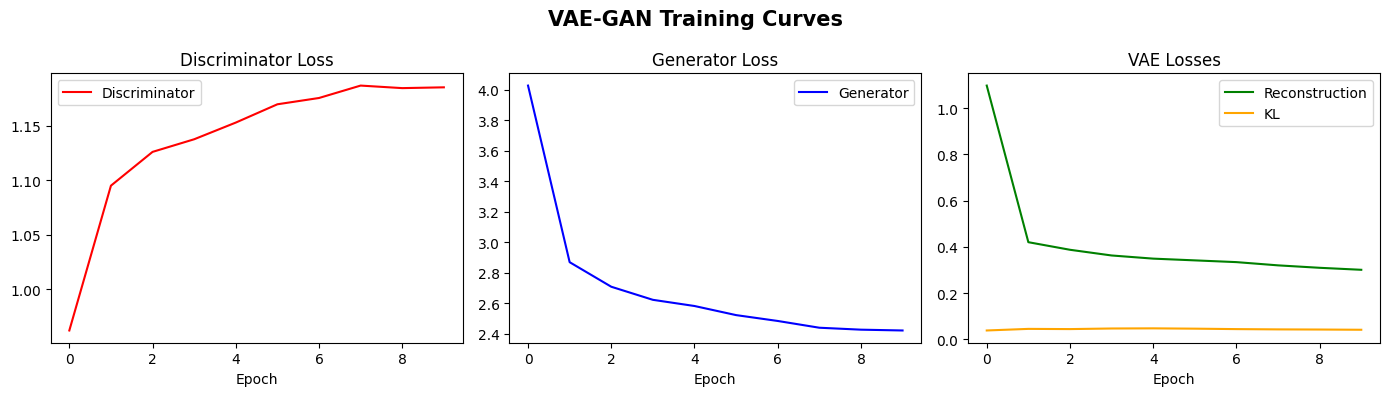

In [8]:
# ── Loss curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('VAE-GAN Training Curves', fontsize=15, fontweight='bold')

axes[0].plot(history['d_loss'], 'r', label='Discriminator')
axes[0].set_title('Discriminator Loss'); axes[0].legend()

axes[1].plot(history['g_loss'], 'b', label='Generator')
axes[1].set_title('Generator Loss'); axes[1].legend()

axes[2].plot(history['rec_loss'], 'g', label='Reconstruction')
axes[2].plot(history['kl_loss'],  'orange', label='KL')
axes[2].set_title('VAE Losses'); axes[2].legend()

for ax in axes:
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

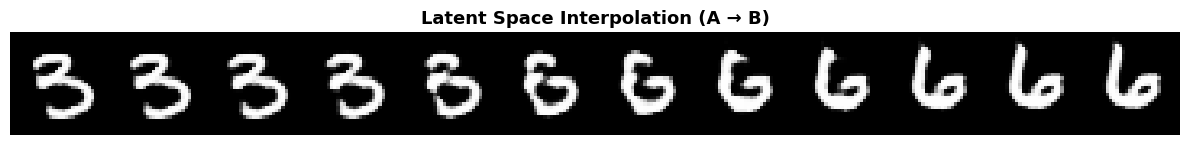

In [9]:
# ── Latent space interpolation ────────────────────────────────────────────────
enc.eval(); dec.eval()
with torch.no_grad():
    # Pick two real images and walk between their latents
    imgs, _ = next(iter(mnist_loader))
    imgs = imgs[:2].to(DEVICE)
    mu1, lv1 = enc(imgs[0:1])
    mu2, lv2 = enc(imgs[1:2])
    interps = []
    for alpha in torch.linspace(0, 1, 12):
        z = (1 - alpha) * mu1 + alpha * mu2
        interps.append(dec(z))
    interps = torch.cat(interps, dim=0)

plot_samples(interps, 'Latent Space Interpolation (A → B)', n=12, figsize=(12, 2))

---
# Part 2 — 3D Voxel GAN

We generate **3D voxel grids** (32×32×32) of primitive shapes — cubes, spheres, cylinders — created procedurally (no external download needed).

Architecture: **3D Transposed Convolutions** in generator, **3D Convolutions** in discriminator.

In [10]:
# ── Synthetic 3D shape dataset ────────────────────────────────────────────────
VOX_SIZE = 32

def make_sphere(size=VOX_SIZE, r_frac=0.35):
    grid = np.zeros((size, size, size), dtype=np.float32)
    c, r = size // 2, size * r_frac
    z, y, x = np.ogrid[:size, :size, :size]
    mask = (x - c)**2 + (y - c)**2 + (z - c)**2 <= r**2
    grid[mask] = 1.0
    return grid

def make_cube(size=VOX_SIZE, fill=0.5):
    grid = np.zeros((size, size, size), dtype=np.float32)
    lo = int(size * (0.5 - fill / 2))
    hi = int(size * (0.5 + fill / 2))
    grid[lo:hi, lo:hi, lo:hi] = 1.0
    return grid

def make_cylinder(size=VOX_SIZE, r_frac=0.3, h_frac=0.6):
    grid = np.zeros((size, size, size), dtype=np.float32)
    c, r = size // 2, size * r_frac
    h_lo = int(size * (0.5 - h_frac / 2))
    h_hi = int(size * (0.5 + h_frac / 2))
    y, x = np.ogrid[:size, :size]
    circ = (x - c)**2 + (y - c)**2 <= r**2
    for z in range(h_lo, h_hi):
        grid[z][circ] = 1.0
    return grid

def make_torus(size=VOX_SIZE, R_frac=0.3, r_frac=0.12):
    grid = np.zeros((size, size, size), dtype=np.float32)
    c = size // 2
    R, r = size * R_frac, size * r_frac
    z_i, y_i, x_i = np.indices((size, size, size))
    x_i -= c; y_i -= c; z_i -= c
    dist = (np.sqrt(x_i**2 + y_i**2) - R)**2 + z_i**2
    grid[dist <= r**2] = 1.0
    return grid

def build_3d_dataset(n=2000):
    makers = [make_sphere, make_cube, make_cylinder, make_torus]
    voxels = []
    for i in range(n):
        fn = makers[i % len(makers)]
        # Add slight random noise to vary each sample
        v = fn() + np.random.normal(0, 0.05, (VOX_SIZE,) * 3).astype(np.float32)
        v = np.clip(v, 0, 1)
        voxels.append(v)
    # Shape: (N, 1, D, H, W)
    arr = np.stack(voxels)[:, np.newaxis]
    return torch.tensor(arr)

print('Building 3D voxel dataset...')
vox_data   = build_3d_dataset(n=2000)
vox_loader = DataLoader(TensorDataset(vox_data), batch_size=32, shuffle=True)
print(f'Dataset shape: {vox_data.shape}  |  dtype: {vox_data.dtype}')

Building 3D voxel dataset...
Dataset shape: torch.Size([2000, 1, 32, 32, 32])  |  dtype: torch.float32


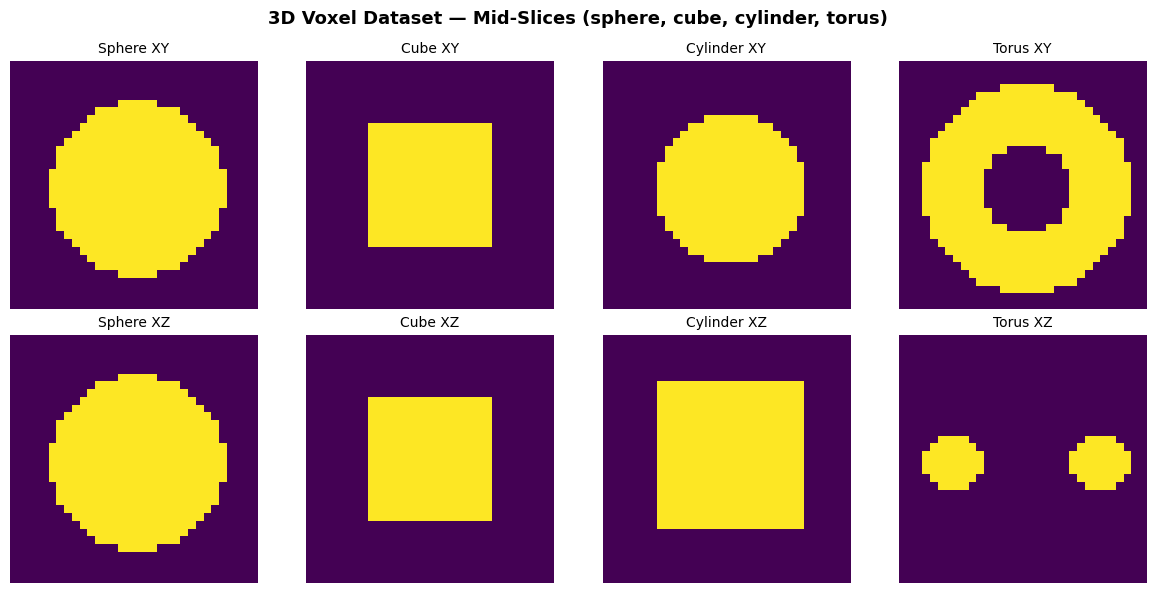

In [11]:
# ── Preview dataset samples ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('3D Voxel Dataset — Mid-Slices (sphere, cube, cylinder, torus)', fontsize=13, fontweight='bold')

labels = ['Sphere', 'Cube', 'Cylinder', 'Torus']
fns    = [make_sphere, make_cube, make_cylinder, make_torus]

for i, (fn, label) in enumerate(zip(fns, labels)):
    v = fn()
    mid = VOX_SIZE // 2
    axes[0, i].imshow(v[mid], cmap='viridis', vmin=0, vmax=1)
    axes[0, i].set_title(f'{label} XY', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(v[:, mid, :], cmap='viridis', vmin=0, vmax=1)
    axes[1, i].set_title(f'{label} XZ', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# ── 3D GAN Architecture ───────────────────────────────────────────────────────
VOX_Z_DIM = 128

class Generator3D(nn.Module):
    """
    z (128,) → 3D voxel (1, 32, 32, 32)
    Uses 3D transposed convolutions: 2→4→8→16→32
    """
    def __init__(self, z_dim=VOX_Z_DIM):
        super().__init__()
        self.fc = nn.Linear(z_dim, 512 * 2 * 2 * 2)
        self.net = nn.Sequential(
            # (512, 2, 2, 2) → (256, 4, 4, 4)
            nn.ConvTranspose3d(512, 256, 4, 2, 1),
            nn.BatchNorm3d(256),
            nn.ReLU(True),
            # → (128, 8, 8, 8)
            nn.ConvTranspose3d(256, 128, 4, 2, 1),
            nn.BatchNorm3d(128),
            nn.ReLU(True),
            # → (64, 16, 16, 16)
            nn.ConvTranspose3d(128, 64, 4, 2, 1),
            nn.BatchNorm3d(64),
            nn.ReLU(True),
            # → (1, 32, 32, 32)
            nn.ConvTranspose3d(64, 1, 4, 2, 1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 512, 2, 2, 2)
        return self.net(h)


class Discriminator3D(nn.Module):
    """
    3D voxel (1, 32, 32, 32) → scalar score
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # (1,32,32,32) → (64,16,16,16)
            nn.Conv3d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, True),
            # → (128,8,8,8)
            nn.Conv3d(64, 128, 4, 2, 1),
            nn.BatchNorm3d(128),
            nn.LeakyReLU(0.2, True),
            # → (256,4,4,4)
            nn.Conv3d(128, 256, 4, 2, 1),
            nn.BatchNorm3d(256),
            nn.LeakyReLU(0.2, True),
            # → (512,2,2,2)
            nn.Conv3d(256, 512, 4, 2, 1),
            nn.BatchNorm3d(512),
            nn.LeakyReLU(0.2, True),
            nn.Flatten(),
            nn.Linear(512 * 2 * 2 * 2, 1),
        )

    def forward(self, x):
        return self.net(x)


gen3d  = Generator3D().to(DEVICE)
disc3d = Discriminator3D().to(DEVICE)

opt_g3 = optim.Adam(gen3d.parameters(),  lr=1e-4, betas=(0.5, 0.999))
opt_d3 = optim.Adam(disc3d.parameters(), lr=1e-4, betas=(0.5, 0.999))

total_gen  = sum(p.numel() for p in gen3d.parameters())
total_disc = sum(p.numel() for p in disc3d.parameters())
print(f'Generator3D params:     {total_gen:,}')
print(f'Discriminator3D params: {total_disc:,}')

Generator3D params:     11,543,873
Discriminator3D params: 11,020,993


In [13]:
# ── 3D Visualisation helper ───────────────────────────────────────────────────
def plot_voxel_slices(voxel, title='Generated 3D Shape', threshold=0.5):
    """Show 3 orthogonal slices of a voxel grid."""
    v = voxel.squeeze().cpu().numpy()
    mid = v.shape[0] // 2
    binary = (v > threshold).astype(float)

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for ax, (slc, name) in zip(axes, [
        (binary[mid],     'XY (z-mid)'),
        (binary[:, mid],  'XZ (y-mid)'),
        (binary[:, :, mid], 'YZ (x-mid)'),
    ]):
        ax.imshow(slc, cmap='plasma', vmin=0, vmax=1)
        ax.set_title(name, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def plot_multi_voxels(voxels, n=4, epoch=0, threshold=0.5):
    """Show multiple generated voxel grids, 3 slices each."""
    fig, axes = plt.subplots(n, 3, figsize=(9, n * 2.5))
    fig.suptitle(f'Generated 3D Voxels — Epoch {epoch}', fontsize=13, fontweight='bold')
    view_names = ['XY', 'XZ', 'YZ']

    for row in range(n):
        v = voxels[row].squeeze().cpu().numpy()
        mid = v.shape[0] // 2
        binary = (v > threshold).astype(float)
        slices = [binary[mid], binary[:, mid], binary[:, :, mid]]

        for col, (slc, name) in enumerate(zip(slices, view_names)):
            axes[row, col].imshow(slc, cmap='plasma', vmin=0, vmax=1)
            if row == 0:
                axes[row, col].set_title(name, fontsize=10)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

Epoch 01 | D: 0.2603 | G: 6.9633


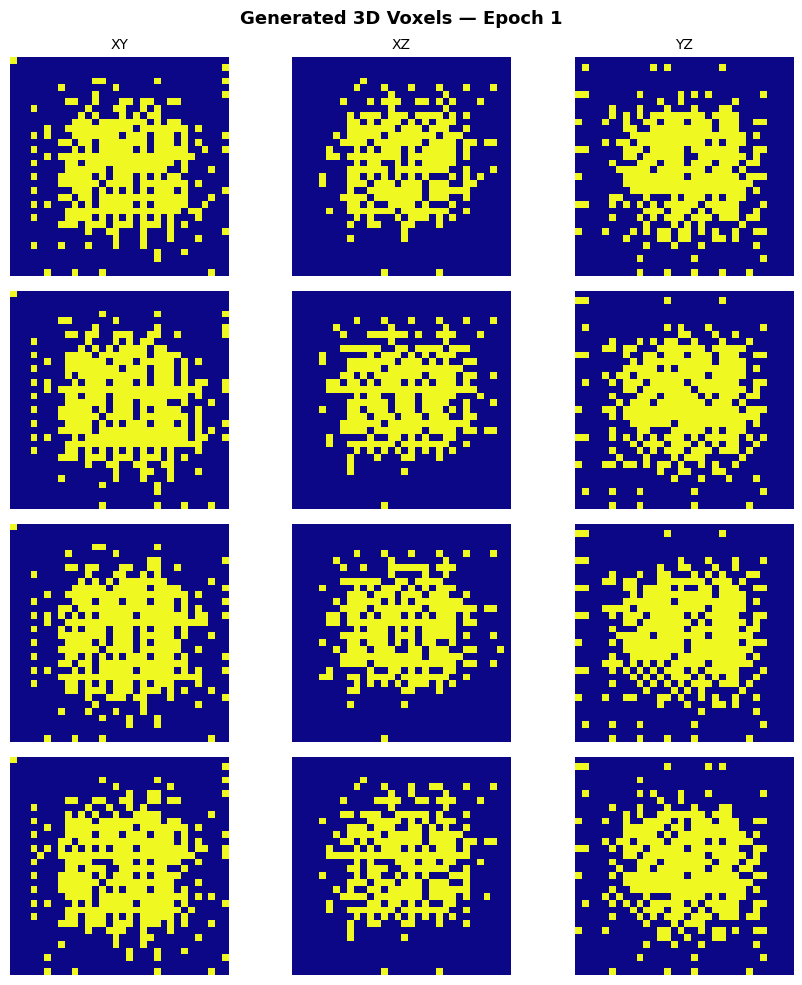

Epoch 02 | D: 0.2030 | G: 6.4309


Epoch 03 | D: 0.2608 | G: 2.6596


Epoch 04 | D: 0.3017 | G: 2.5315


Epoch 05 | D: 0.2652 | G: 3.0704


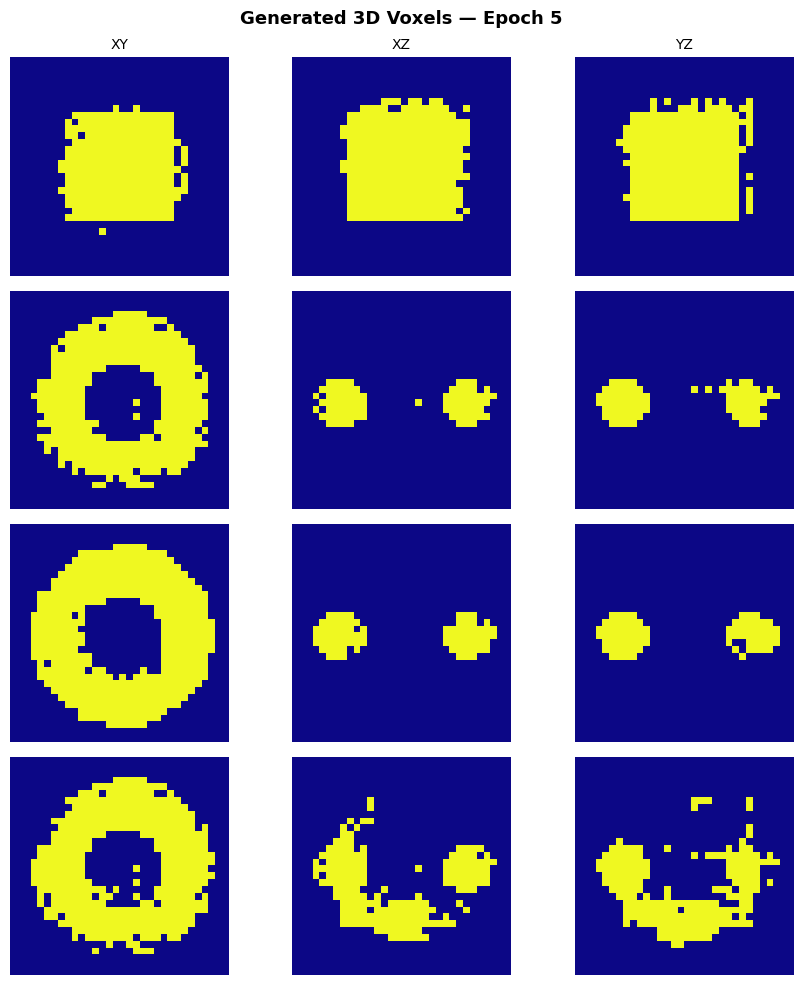

Epoch 06 | D: 0.3640 | G: 2.3440


Epoch 07 | D: 0.3462 | G: 2.4247


Epoch 08 | D: 0.3296 | G: 2.5229


Epoch 09 | D: 0.2887 | G: 2.6471


Epoch 10 | D: 0.3029 | G: 2.5870


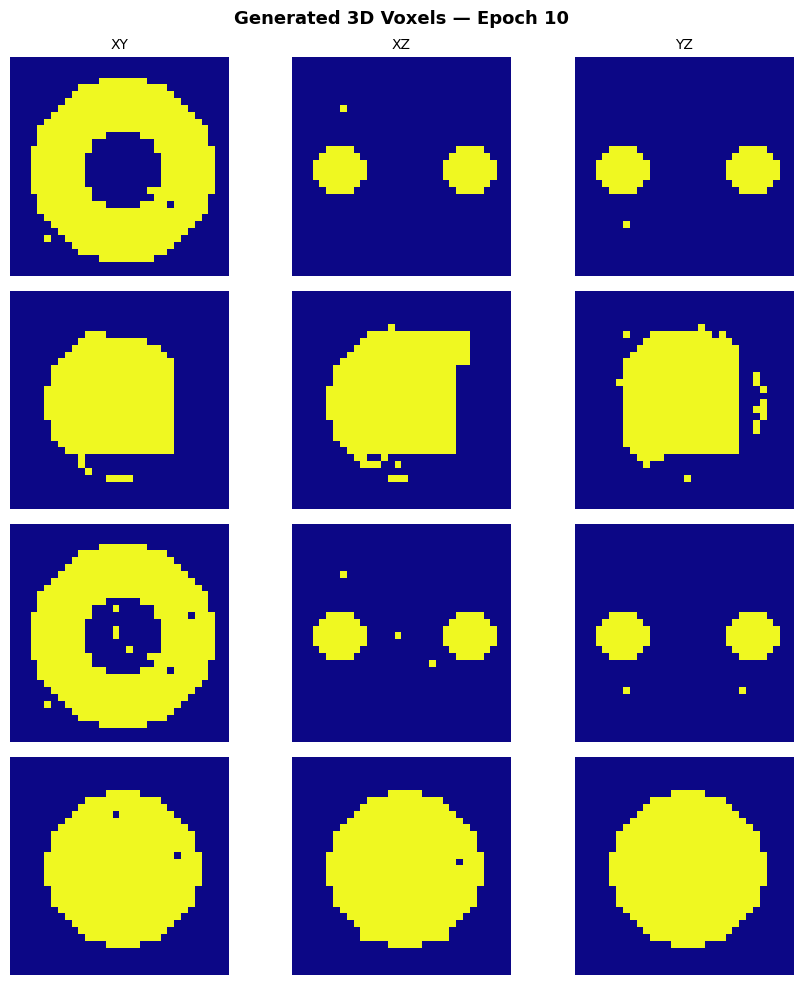

Epoch 11 | D: 0.4638 | G: 1.7201


Epoch 12 | D: 0.2707 | G: 2.6709


Epoch 13 | D: 0.3732 | G: 2.2680


Epoch 14 | D: 0.2986 | G: 2.5717


Epoch 15 | D: 0.3454 | G: 2.3248


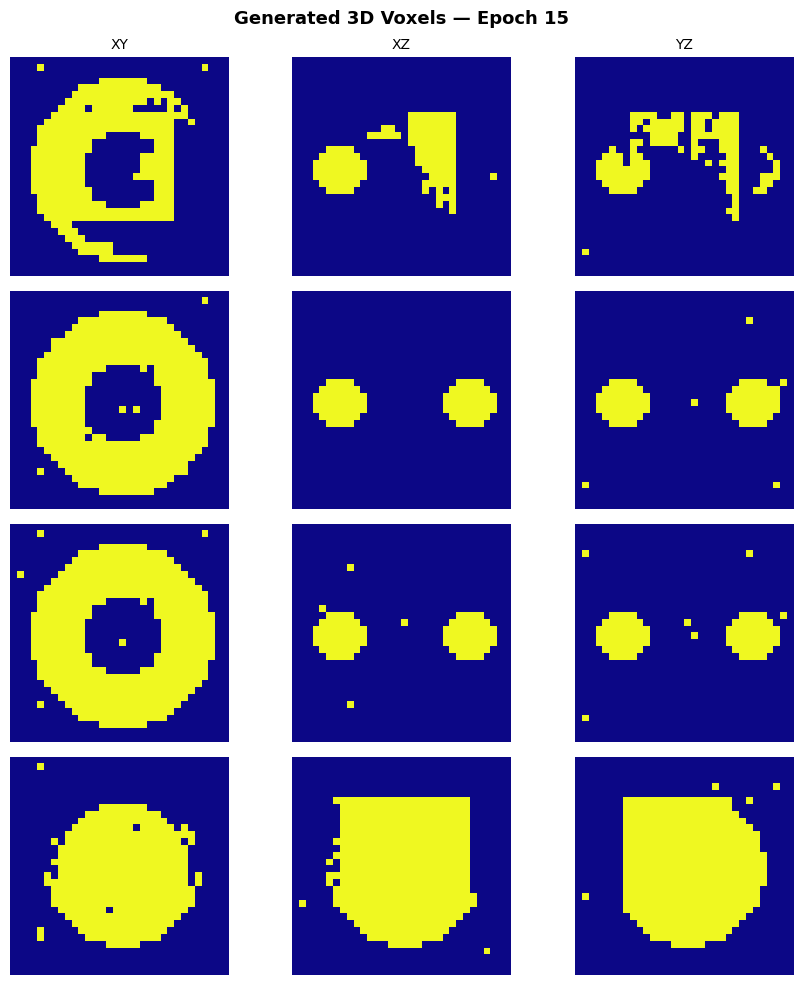

In [14]:
# ── 3D GAN Training ───────────────────────────────────────────────────────────
GAN3D_EPOCHS = 15
fixed_z3d = torch.randn(4, VOX_Z_DIM, device=DEVICE)

hist3d = {'d': [], 'g': []}

for epoch in range(1, GAN3D_EPOCHS + 1):
    gen3d.train(); disc3d.train()
    ep_d, ep_g = 0., 0.

    for (real,) in tqdm(vox_loader, desc=f'3D-GAN Epoch {epoch}/{GAN3D_EPOCHS}', leave=False):
        real = real.to(DEVICE)
        bs   = real.size(0)
        ones  = torch.ones(bs, 1, device=DEVICE)
        zeros = torch.zeros(bs, 1, device=DEVICE)

        # ── Discriminator ────────────────────────────────────────────────────
        z    = torch.randn(bs, VOX_Z_DIM, device=DEVICE)
        fake = gen3d(z).detach()

        opt_d3.zero_grad()
        d_real  = bce(disc3d(real), ones)
        d_fake  = bce(disc3d(fake), zeros)
        d_loss  = (d_real + d_fake) * 0.5
        d_loss.backward()
        opt_d3.step()

        # ── Generator ────────────────────────────────────────────────────────
        opt_g3.zero_grad()
        z    = torch.randn(bs, VOX_Z_DIM, device=DEVICE)
        fake = gen3d(z)
        g_loss = bce(disc3d(fake), ones)
        g_loss.backward()
        opt_g3.step()

        ep_d += d_loss.item()
        ep_g += g_loss.item()

    n = len(vox_loader)
    hist3d['d'].append(ep_d / n)
    hist3d['g'].append(ep_g / n)
    print(f'Epoch {epoch:02d} | D: {ep_d/n:.4f} | G: {ep_g/n:.4f}')

    if epoch % 5 == 0 or epoch == 1:
        gen3d.eval()
        with torch.no_grad():
            vox_samples = gen3d(fixed_z3d)
        plot_multi_voxels(vox_samples, n=4, epoch=epoch)

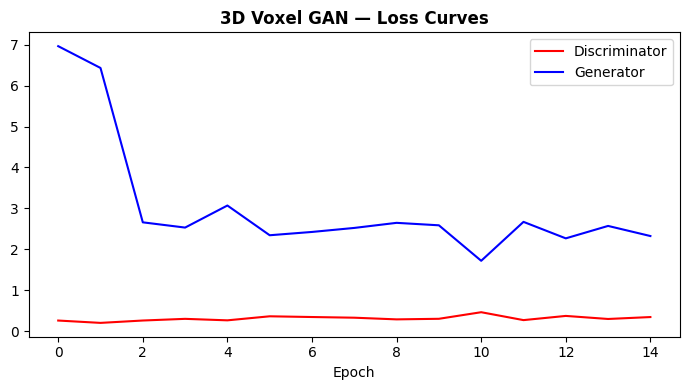

In [15]:
# ── 3D Loss curves ────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(hist3d['d'], 'r', label='Discriminator')
plt.plot(hist3d['g'], 'b', label='Generator')
plt.title('3D Voxel GAN — Loss Curves', fontweight='bold')
plt.xlabel('Epoch'); plt.legend(); plt.tight_layout(); plt.show()

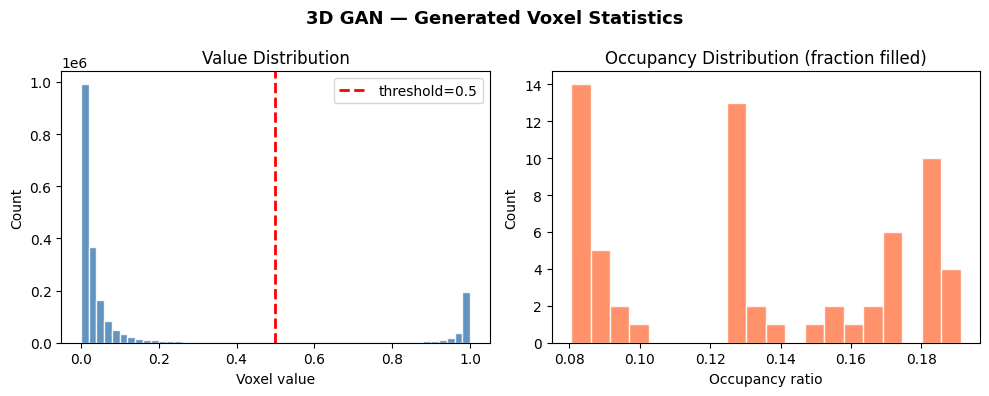

In [16]:
# ── Occupancy occupancy density histogram ─────────────────────────────────────
gen3d.eval()
with torch.no_grad():
    z_test  = torch.randn(64, VOX_Z_DIM, device=DEVICE)
    samples = gen3d(z_test).cpu().numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('3D GAN — Generated Voxel Statistics', fontsize=13, fontweight='bold')

axes[0].hist(samples, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='red', lw=2, linestyle='--', label='threshold=0.5')
axes[0].set_xlabel('Voxel value'); axes[0].set_ylabel('Count')
axes[0].set_title('Value Distribution'); axes[0].legend()

# Occupancy per sample
occ = (gen3d(torch.randn(64, VOX_Z_DIM, device=DEVICE)) > 0.5).float()
occ = occ.cpu().numpy().reshape(64, -1).mean(axis=1)
axes[1].hist(occ, bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Occupancy ratio'); axes[1].set_ylabel('Count')
axes[1].set_title('Occupancy Distribution (fraction filled)')

plt.tight_layout(); plt.show()

---
# Part 3 — DDPM (Denoising Diffusion Probabilistic Model)

DDPM defines:
- **Forward process** `q(x_t | x_{t-1})` — gradually adds Gaussian noise over T steps
- **Reverse process** `p_θ(x_{t-1} | x_t)` — a U-Net learns to *predict* and remove the noise

At inference, we start from pure noise `x_T ~ N(0,I)` and iteratively denoise.

We use **MNIST** for fast training with a lightweight U-Net.

In [17]:
# ── Noise schedule ────────────────────────────────────────────────────────────
T         = 500          # diffusion timesteps
BETA_MIN  = 1e-4
BETA_MAX  = 0.02

betas     = torch.linspace(BETA_MIN, BETA_MAX, T, device=DEVICE)
alphas    = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)          # ᾱ_t = ∏ α_i
sqrt_ab   = alpha_bar.sqrt()
sqrt_1mab = (1.0 - alpha_bar).sqrt()

def q_sample(x0, t, noise=None):
    """Sample x_t given x_0 at timestep t using closed-form."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab_t  = sqrt_ab[t].view(-1, 1, 1, 1)
    sqrt_1m_t  = sqrt_1mab[t].view(-1, 1, 1, 1)
    return sqrt_ab_t * x0 + sqrt_1m_t * noise, noise


# Quick sanity check
x_sample = torch.randn(4, 1, 28, 28, device=DEVICE)
t_sample  = torch.randint(0, T, (4,), device=DEVICE)
x_noisy, _ = q_sample(x_sample, t_sample)
print(f'Noisy sample shape: {x_noisy.shape}')

Noisy sample shape: torch.Size([4, 1, 28, 28])


In [18]:
# ── Lightweight U-Net for noise prediction ────────────────────────────────────
class SinusoidalPE(nn.Module):
    """Sinusoidal position encoding for timestep embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=device) * (np.log(10000) / (half - 1))
        ).float()
        args  = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (B, dim)


class ResBlock(nn.Module):
    """Residual conv block with timestep conditioning."""
    def __init__(self, in_c, out_c, t_emb_dim):
        super().__init__()
        self.conv1 = nn.Sequential(nn.GroupNorm(8, in_c), nn.SiLU(),
                                   nn.Conv2d(in_c, out_c, 3, 1, 1))
        self.t_proj = nn.Sequential(nn.SiLU(), nn.Linear(t_emb_dim, out_c))
        self.conv2 = nn.Sequential(nn.GroupNorm(8, out_c), nn.SiLU(),
                                   nn.Conv2d(out_c, out_c, 3, 1, 1))
        self.skip  = nn.Conv2d(in_c, out_c, 1) if in_c != out_c else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.t_proj(t_emb)[:, :, None, None]
        h = self.conv2(h)
        return h + self.skip(x)


class UNet(nn.Module):
    """
    Lightweight U-Net for MNIST (28x28).
    Channels: 64 → 128 → 256, then symmetric decoder.
    """
    def __init__(self, img_channels=1, base_ch=64, t_dim=128):
        super().__init__()
        self.t_emb = nn.Sequential(
            SinusoidalPE(t_dim),
            nn.Linear(t_dim, t_dim * 2),
            nn.SiLU(),
            nn.Linear(t_dim * 2, t_dim),
        )

        c = base_ch
        # Encoder
        self.in_conv = nn.Conv2d(img_channels, c, 3, 1, 1)
        self.enc1    = ResBlock(c,      c,     t_dim)   # 28x28
        self.down1   = nn.Conv2d(c,     c*2,   4, 2, 1) # 14x14
        self.enc2    = ResBlock(c*2,    c*2,   t_dim)
        self.down2   = nn.Conv2d(c*2,   c*4,   4, 2, 1) # 7x7
        self.enc3    = ResBlock(c*4,    c*4,   t_dim)

        # Bottleneck
        self.mid     = ResBlock(c*4,    c*4,   t_dim)

        # Decoder
        self.up2     = nn.ConvTranspose2d(c*4,   c*2, 4, 2, 1)  # 14x14
        self.dec2    = ResBlock(c*4,    c*2,   t_dim)  # skip concat doubles channels
        self.up1     = nn.ConvTranspose2d(c*2,   c,   4, 2, 1)  # 28x28
        self.dec1    = ResBlock(c*2,    c,     t_dim)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, c), nn.SiLU(),
            nn.Conv2d(c, img_channels, 3, 1, 1)
        )

    def forward(self, x, t):
        te = self.t_emb(t)

        # Encoder
        x0 = self.in_conv(x)          # (B, c, 28, 28)
        x1 = self.enc1(x0, te)        # (B, c, 28, 28)
        x2 = self.enc2(self.down1(x1), te)  # (B, 2c, 14, 14)
        x3 = self.enc3(self.down2(x2), te)  # (B, 4c, 7, 7)

        # Bottleneck
        h  = self.mid(x3, te)

        # Decoder with skip connections
        h  = self.dec2(torch.cat([self.up2(h), x2], dim=1), te)
        h  = self.dec1(torch.cat([self.up1(h), x1], dim=1), te)
        return self.out_conv(h)


unet = UNet().to(DEVICE)
n_params = sum(p.numel() for p in unet.parameters())
print(f'U-Net parameters: {n_params:,}')

# Sanity check
with torch.no_grad():
    test_x = torch.randn(4, 1, 28, 28, device=DEVICE)
    test_t = torch.randint(0, T, (4,), device=DEVICE)
    out = unet(test_x, test_t)
print(f'U-Net output shape: {out.shape}  ✓')

U-Net parameters: 4,821,953
U-Net output shape: torch.Size([4, 1, 28, 28])  ✓


In [19]:
# ── Reverse-process sampler (DDPM) ────────────────────────────────────────────
@torch.no_grad()
def ddpm_sample(model, n=16, img_size=28, channels=1, stride=1):
    """
    Ancestral sampling from x_T → x_0.
    stride: skip factor for speed (stride=2 → 250 steps)
    """
    model.eval()
    x = torch.randn(n, channels, img_size, img_size, device=DEVICE)
    timesteps = list(range(0, T, stride))[::-1]

    for i, t_idx in enumerate(timesteps):
        t_batch = torch.full((n,), t_idx, device=DEVICE, dtype=torch.long)
        eps_hat = model(x, t_batch)

        beta_t   = betas[t_idx]
        alpha_t  = alphas[t_idx]
        ab_t     = alpha_bar[t_idx]

        # Compute predicted x_0
        x0_pred  = (x - (1.0 - ab_t).sqrt() * eps_hat) / ab_t.sqrt()
        x0_pred  = x0_pred.clamp(-1, 1)

        # Mean of posterior
        if t_idx == 0:
            x = x0_pred
        else:
            ab_prev = alpha_bar[t_idx - stride] if t_idx >= stride else torch.tensor(1.0, device=DEVICE)
            coeff1  = (ab_prev.sqrt() * beta_t) / (1.0 - ab_t)
            coeff2  = ((1.0 - ab_prev) * alpha_t.sqrt()) / (1.0 - ab_t)
            mean    = coeff1 * x0_pred + coeff2 * x
            var     = beta_t * (1.0 - ab_prev) / (1.0 - ab_t)
            noise   = torch.randn_like(x) if t_idx > stride else 0.0
            x       = mean + var.sqrt() * noise
    return x

Epoch 01 | Loss: 0.0729 | LR: 1.95e-04


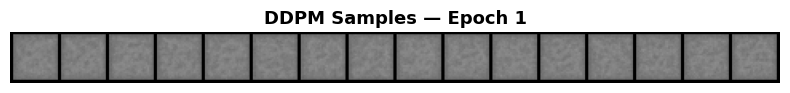

Epoch 02 | Loss: 0.0409 | LR: 1.81e-04


Epoch 03 | Loss: 0.0373 | LR: 1.59e-04


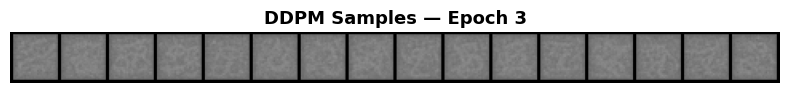

Epoch 04 | Loss: 0.0358 | LR: 1.31e-04


Epoch 05 | Loss: 0.0347 | LR: 1.00e-04


Epoch 06 | Loss: 0.0337 | LR: 6.91e-05


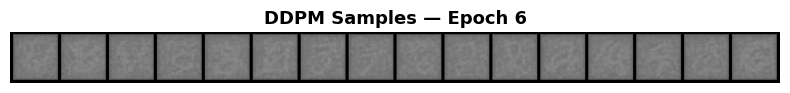

Epoch 07 | Loss: 0.0335 | LR: 4.12e-05


Epoch 08 | Loss: 0.0329 | LR: 1.91e-05


Epoch 09 | Loss: 0.0323 | LR: 4.89e-06


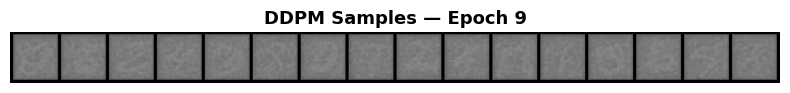

Epoch 10 | Loss: 0.0324 | LR: 0.00e+00


In [20]:
# ── DDPM Training ─────────────────────────────────────────────────────────────
opt_ddpm = optim.Adam(unet.parameters(), lr=2e-4)
scheduler_ddpm = optim.lr_scheduler.CosineAnnealingLR(opt_ddpm, T_max=10)

DDPM_EPOCHS = 10
hist_ddpm   = []

for epoch in range(1, DDPM_EPOCHS + 1):
    unet.train()
    ep_loss = 0.0

    for real, _ in tqdm(mnist_loader, desc=f'DDPM Epoch {epoch}/{DDPM_EPOCHS}', leave=False):
        real  = real.to(DEVICE)
        bs    = real.size(0)
        t     = torch.randint(0, T, (bs,), device=DEVICE)
        noise = torch.randn_like(real)

        x_noisy, _  = q_sample(real, t, noise)
        eps_pred     = unet(x_noisy, t)

        loss = F.mse_loss(eps_pred, noise)

        opt_ddpm.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(unet.parameters(), 1.0)
        opt_ddpm.step()

        ep_loss += loss.item()

    scheduler_ddpm.step()
    avg_loss = ep_loss / len(mnist_loader)
    hist_ddpm.append(avg_loss)
    print(f'Epoch {epoch:02d} | Loss: {avg_loss:.4f} | LR: {scheduler_ddpm.get_last_lr()[0]:.2e}')

    if epoch % 3 == 0 or epoch == 1:
        samples = ddpm_sample(unet, n=16, stride=2)
        plot_samples(samples, f'DDPM Samples — Epoch {epoch}')

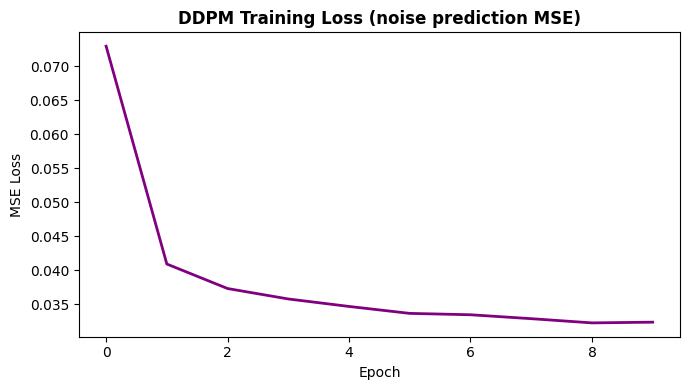

In [21]:
# ── DDPM loss curve ───────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(hist_ddpm, 'purple', lw=2)
plt.title('DDPM Training Loss (noise prediction MSE)', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.tight_layout(); plt.show()

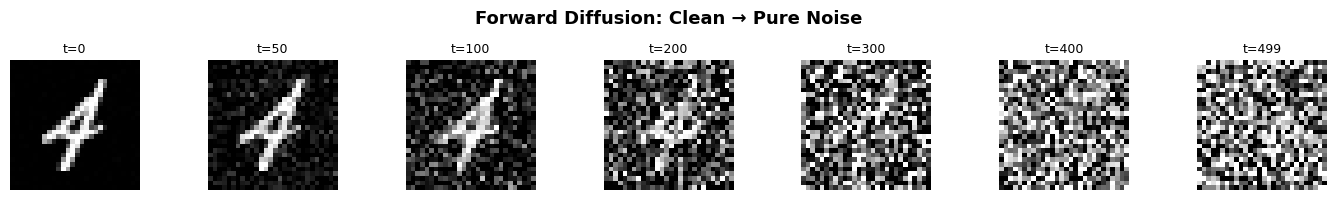

In [22]:
# ── Visualise diffusion forward process ───────────────────────────────────────
imgs, _ = next(iter(mnist_loader))
x0 = imgs[0:1].to(DEVICE)   # single image

timesteps_vis = [0, 50, 100, 200, 300, 400, 499]
fig, axes = plt.subplots(1, len(timesteps_vis), figsize=(14, 2))
fig.suptitle('Forward Diffusion: Clean → Pure Noise', fontsize=13, fontweight='bold')

for ax, t_val in zip(axes, timesteps_vis):
    t_tensor = torch.tensor([t_val], device=DEVICE)
    x_noisy, _ = q_sample(x0, t_tensor)
    img = x_noisy[0].cpu().squeeze() * 0.5 + 0.5
    ax.imshow(img.clamp(0, 1), cmap='gray')
    ax.set_title(f't={t_val}', fontsize=9)
    ax.axis('off')

plt.tight_layout(); plt.show()

Generating reverse denoising trajectory (this takes ~30s on CPU)...


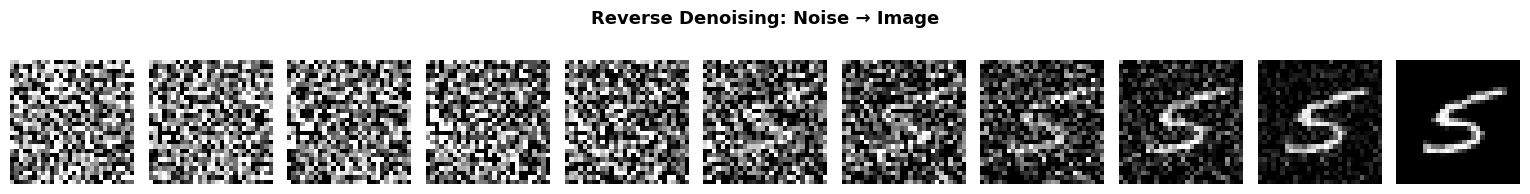

In [23]:
# ── Visualise reverse denoising trajectory ────────────────────────────────────
@torch.no_grad()
def ddpm_sample_trajectory(model, n=1, stride=50):
    """Returns samples at select reverse timesteps."""
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=DEVICE)
    trajectory = [x.clone()]
    timesteps  = list(range(0, T, 1))[::-1]
    checkpoints = set(range(0, T, stride))

    for t_idx in timesteps:
        t_batch  = torch.full((n,), t_idx, device=DEVICE, dtype=torch.long)
        eps_hat  = model(x, t_batch)
        beta_t   = betas[t_idx]
        alpha_t  = alphas[t_idx]
        ab_t     = alpha_bar[t_idx]
        x0_pred  = (x - (1.0 - ab_t).sqrt() * eps_hat) / ab_t.sqrt()
        x0_pred  = x0_pred.clamp(-1, 1)
        if t_idx == 0:
            x = x0_pred
        else:
            ab_prev = alpha_bar[t_idx - 1]
            coeff1  = (ab_prev.sqrt() * beta_t) / (1.0 - ab_t)
            coeff2  = ((1.0 - ab_prev) * alpha_t.sqrt()) / (1.0 - ab_t)
            mean    = coeff1 * x0_pred + coeff2 * x
            var     = beta_t * (1.0 - ab_prev) / (1.0 - ab_t)
            x       = mean + var.sqrt() * torch.randn_like(x)

        if t_idx in checkpoints:
            trajectory.append(x.clone())

    return trajectory


print('Generating reverse denoising trajectory (this takes ~30s on CPU)...')
traj = ddpm_sample_trajectory(unet, n=1, stride=50)

n_steps = len(traj)
fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.4, 2))
fig.suptitle('Reverse Denoising: Noise → Image', fontsize=13, fontweight='bold')

for ax, frame in zip(axes, traj):
    img = frame[0, 0].cpu() * 0.5 + 0.5
    ax.imshow(img.clamp(0, 1), cmap='gray')
    ax.axis('off')

plt.tight_layout(); plt.show()

---
# Summary & Comparison

| Model | Strengths | Weaknesses | Best for |
|---|---|---|---|
| **VAE-GAN** | Sharp images + structured latent space | Mode collapse risk, harder to tune | Interpolation, editing, fast sampling |
| **3D Voxel GAN** | Volumetric output, 3D-aware | Memory heavy, resolution limited | Shape generation, 3D understanding |
| **DDPM** | Highest quality, stable training | Very slow sampling (T steps) | Photorealistic generation, score matching |

## Next Steps
- **VAE-GAN**: Try on CIFAR-10, add attention blocks, swap to spectral norm
- **3D GAN**: Upgrade to PointCloud GAN or NeRF-based generation
- **DDPM**: Add DDIM fast sampler (50 steps), classifier-free guidance, try on CelebA
- **Combine**: Latent Diffusion Models (LDM) = DDPM in VAE latent space → Stable Diffusion!